# Quantum Gibbs sampler — run notebook

This notebook only *runs* the code. All function and class definitions live in `definitions.py` (same folder) and are imported below.

- Three Lindbladian constructions: time domain, frequency domain, and Anthony's construction.
- Sanity checks that all three constructions agree.
- A convergence-time sweep over `sigma` and `beta`, with comparison plots.

## Imports

Pull in everything from `definitions.py`.

In [110]:
from __future__ import annotations
import sys
import time
import itertools
import random
from typing import Callable, Dict, List, Optional, Sequence, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.linalg import eigh, expm

sys.path.append('..')
from gibbs_state_prep.helpers import ising_1d, heisenberg_1d, compute_trace_distance, I, X, Y, Z, kron, kron_n
from gibbs_state_prep.algorithm.preparation import IntegrationGrid
from gibbs_state_prep.exact.gibbs_state import GibbsState

from definitions import *

# Para

In [111]:
number_of_spins = 3
J = 1
h = 0.8

## Build the local Z jump operators

In [112]:
coupling_ops = normalized_simple_jumps(number_of_spins)

## Sanity check: fast linear-algebra helpers

Checks the vectorized NumPy replacements for the old qutip operations against brute-force reference implementations on random operators.

In [113]:
validate_fast_linear_algebra()

All fast linear-algebra identities match their reference implementations.


## Check that all three Lindbladian constructions agree

Build the Hamiltonian, pick a random $\sigma$ and $\beta$, construct the Lindbladian with all three methods, and compare the $L^\dagger(I)=0$ / detailed-balance residuals plus the pairwise differences between constructions.

In [114]:
hamiltonian = ising_1d(n=number_of_spins, J= J ,h= h, periodic=True )

sigma_value = random.uniform(0,2)
beta_value = random.uniform(0,2)
S_value = 10

int_grid = IntegrationGrid(10,10201)

print("The random sigma is = ", sigma_value)
print("The random beta is = ", beta_value)
print(f"t_max used for this beta = {int_grid.t_max:.4g}")
print('')

eig_cache_single: Dict = {}
lindbladians = {}
gibbs_states = {}
d = hamiltonian.shape[0]

for name, builder in CONSTRUCTION_METHODS.items():
    Lind, rho_g = builder(hamiltonian, beta_value, sigma_value, S_value, int_grid, coupling_ops,
                           q_filter="metropolis_bumped", eig_cache=eig_cache_single)
    lindbladians[name] = Lind
    gibbs_states[name] = rho_g
    print(f"[{name}]")
    print(f"  max|L^dagger(I)|          = {l_dagger_identity_residual(Lind, d):.3e}")
    print(f"  detailed-balance residual = {detailed_balance_residual(Lind, rho_g):.3e}")

Lindbladian, rho_gibbs = lindbladians["frequency_domain"], gibbs_states["frequency_domain"]

print("\nPairwise Lindbladian differences (relative Frobenius norm; constructions can differ by\n"
      "an overall normalization/convention, so look for *consistency*, not exact equality):")
names = list(lindbladians)
for i in range(len(names)):
    for j in range(i + 1, len(names)):
        a, b = lindbladians[names[i]], lindbladians[names[j]]
        rel = np.linalg.norm(a - b, 'fro') / np.linalg.norm(a, 'fro')
        print(f"  {names[i]:17s} vs {names[j]:17s}: {rel:.4g}")

The random sigma is =  1.9567648005482723
The random beta is =  0.9926438752990343
t_max used for this beta = 10



/Users/lorisweber/Desktop/Roberts_Gibbs_sampler/definitions.py:362: RuntimeWarning: overflow encountered in exp
  return np.exp(-nu**2 / (8 * sigma**2)) / (1 + np.exp(beta * nu / 2))


[time_domain]
  max|L^dagger(I)|          = 2.256e-14
  detailed-balance residual = 5.645e-07
[frequency_domain]
  max|L^dagger(I)|          = 1.475e-15
  detailed-balance residual = 1.030e-12
[anthony]
  max|L^dagger(I)|          = 1.128e-14
  detailed-balance residual = 5.645e-07
[anthony_bohr]
  max|L^dagger(I)|          = 1.681e-14
  detailed-balance residual = 1.030e-12

Pairwise Lindbladian differences (relative Frobenius norm; constructions can differ by
an overall normalization/convention, so look for *consistency*, not exact equality):
  time_domain       vs frequency_domain : 4.847e-06
  time_domain       vs anthony          : 3.925e-14
  time_domain       vs anthony_bohr     : 4.847e-06
  frequency_domain  vs anthony          : 4.847e-06
  frequency_domain  vs anthony_bohr     : 5.935e-13
  anthony           vs anthony_bohr     : 4.847e-06


## Convergence-time sweep for frequency domain

Runs the sweep across every construction, sigma, and beta combination and records the convergence time plus the two structural diagnostics (L^dagger(I) residual, detailed-balance residual).

In [ ]:
sigma_values = np.linspace(0.1,10,10)
beta_values = np.linspace(0.3,1,4)

q_filter_ = 'gaussian'
threshold_value = 1e-2
max_evo_time = 1e6
method_for_evo = 'SPECTRAL' #RK4 much slower then 'SPECTRAL'

results_df = run_convergence_sweep(
    hamiltonian, sigma_values, beta_values, grid_with_sigma_and_beta_dependency, S_value, coupling_ops,
    constructions= ( "frequency_domain", 'anthony_bohr'),
    q_filter=q_filter_, threshold= threshold_value, max_time=max_evo_time, method=method_for_evo)

n_invalid = (~results_df["valid_generator"]).sum()
print(f"{n_invalid} / {len(results_df)} grid points have an invalid generator "
      f"(failed L^dagger(I)=0 or detailed balance), broken down by construction:")
print(results_df.groupby("construction")["valid_generator"].agg(lambda s: (~s).sum()))

results_df

[1/80] frequency_domain  sigma=0.1 beta=0.3 -> t_conv=14.0068  L+_res=6.73e-16  DB_res=2.49e-13  spectral_gap 0.207381 
[2/80] frequency_domain  sigma=0.1 beta=0.5333 -> t_conv=20.9276  L+_res=4.37e-16  DB_res=5.29e-13  spectral_gap 0.151733 
[3/80] frequency_domain  sigma=0.1 beta=0.7667 -> t_conv=39.6876  L+_res=3.26e-16  DB_res=8.26e-13  spectral_gap 0.081322 
[4/80] frequency_domain  sigma=0.1 beta=1 -> t_conv=99.2372  L+_res=3.33e-16  DB_res=1.07e-12  spectral_gap 0.032476 
[5/80] frequency_domain  sigma=1.2 beta=0.3 -> t_conv=15.0355  L+_res=1.28e-15  DB_res=3.20e-13  spectral_gap 0.155252 
[6/80] frequency_domain  sigma=1.2 beta=0.5333 -> t_conv=22.3491  L+_res=1.24e-15  DB_res=6.19e-13  spectral_gap 0.141586 
[7/80] frequency_domain  sigma=1.2 beta=0.7667 -> t_conv=42.0854  L+_res=1.30e-15  DB_res=9.00e-13  spectral_gap 0.076645 
[8/80] frequency_domain  sigma=1.2 beta=1 -> t_conv=103.861  L+_res=8.19e-16  DB_res=1.11e-12  spectral_gap 0.031036 
[9/80] frequency_domain  sigma=2

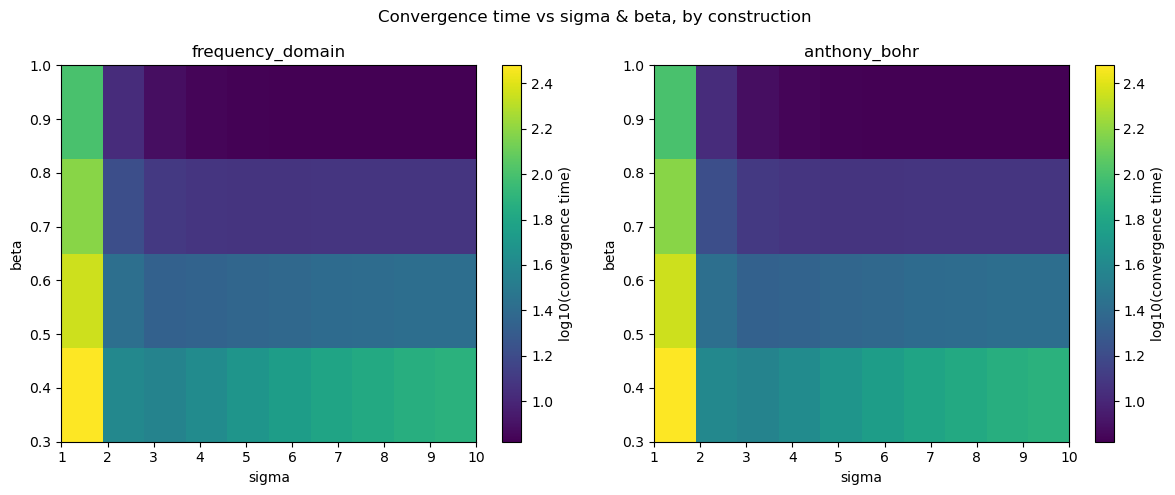

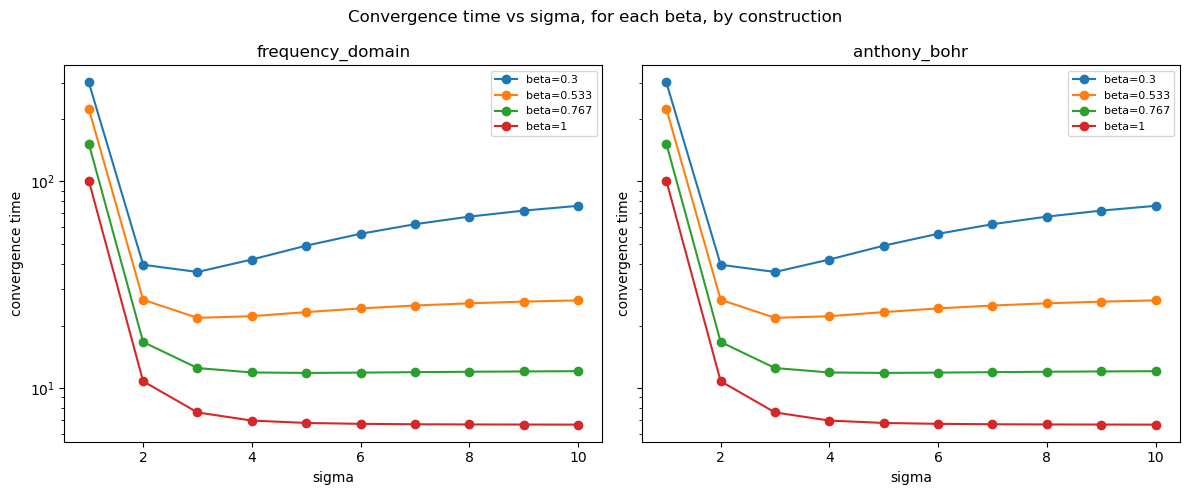

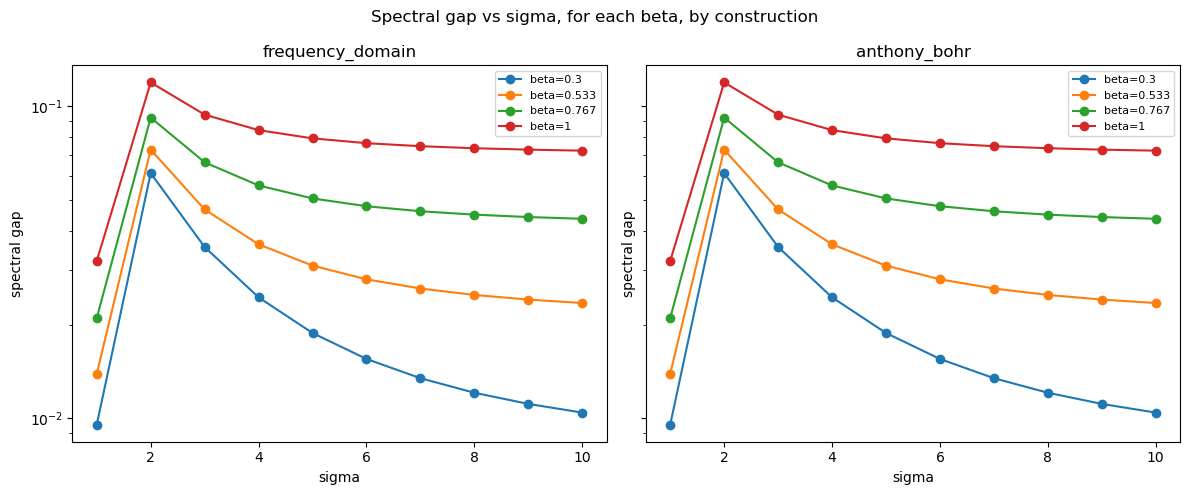

In [ ]:
plot_convergence_heatmap(results_df)
plot_convergence_lines(results_df)
plot_spectral_gap_lines(results_df) 

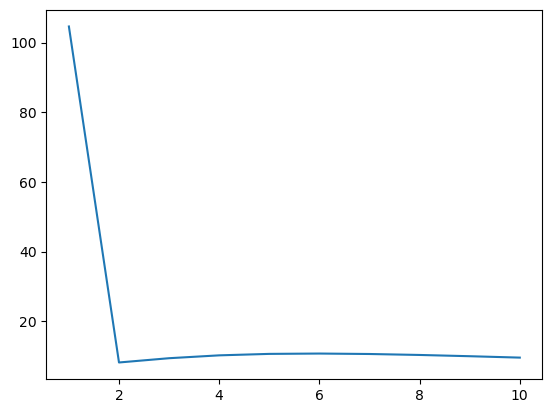

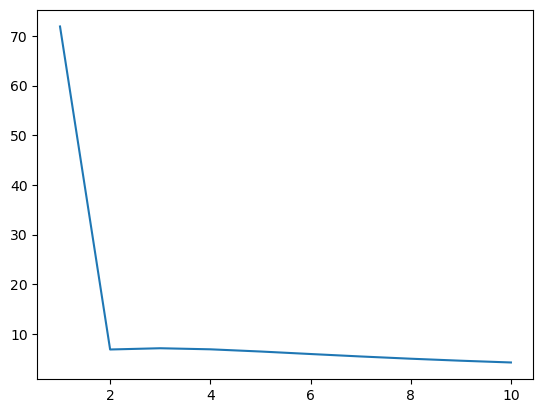

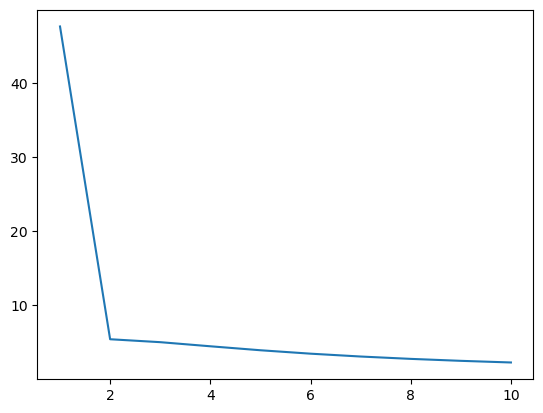

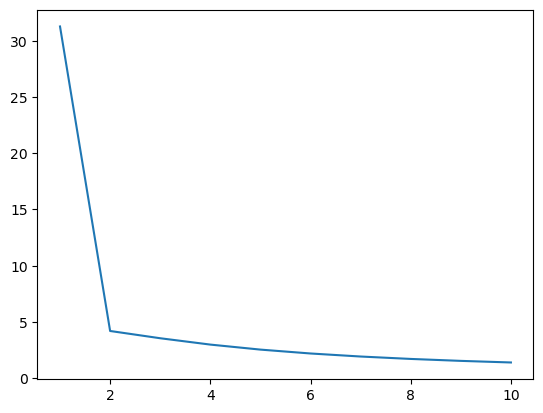

In [ ]:
for ii in range(len(beta_values)):
    beta_choice = beta_values[ii]             
    construction_choice = "anthony_bohr"  

    
    subset = results_df[
        (results_df["construction"] == construction_choice)
        & np.isclose(results_df["beta"], beta_choice)
    ].sort_values("sigma")

    sigma_array = subset["sigma"].to_numpy()
    spectral_gap_array = subset["spectral_gap"].to_numpy()

    weighted = 1/ (sigma_array * spectral_gap_array)
    plt.plot(sigma_array, weighted)
    plt.show()


## Convergence-time sweep for time domain (separated since takes very long)

Runs the sweep across every construction, sigma, and beta combination and records the convergence time plus the two structural diagnostics (L^dagger(I) residual, detailed-balance residual).

In [125]:
results_df_time_domain = run_convergence_sweep(
    hamiltonian, sigma_values, beta_values, grid_with_sigma_and_beta_dependency, S_value, coupling_ops,
    constructions= ( "time_domain",),
    q_filter=q_filter_, threshold= threshold_value, max_time=max_evo_time, method=method_for_evo)

n_invalid = (~results_df_time_domain["valid_generator"]).sum()
print(f"{n_invalid} / {len(results_df_time_domain)} grid points have an invalid generator "
      f"(failed L^dagger(I)=0 or detailed balance), broken down by construction:")
print(results_df_time_domain.groupby("construction")["valid_generator"].agg(lambda s: (~s).sum()))

results_df_time_domain

[1/80] time_domain       sigma=0.1 beta=0.3 -> t_conv=14.0602  L+_res=6.35e-14  DB_res=1.12e-16  spectral_gap 0.206598 
[2/80] time_domain       sigma=0.1 beta=0.5333 -> t_conv=20.9529  L+_res=5.84e-14  DB_res=2.02e-16  spectral_gap 0.151550 
[3/80] time_domain       sigma=0.1 beta=0.7667 -> t_conv=39.6946  L+_res=5.60e-14  DB_res=1.69e-16  spectral_gap 0.081308 
[4/80] time_domain       sigma=0.1 beta=1 -> t_conv=99.2383  L+_res=5.25e-14  DB_res=2.73e-16  spectral_gap 0.032475 
[5/80] time_domain       sigma=0.6211 beta=0.3 -> t_conv=14.0617  L+_res=6.39e-14  DB_res=1.27e-16  spectral_gap 0.206575 
[6/80] time_domain       sigma=0.6211 beta=0.5333 -> t_conv=20.955  L+_res=6.04e-14  DB_res=2.49e-16  spectral_gap 0.151533 
[7/80] time_domain       sigma=0.6211 beta=0.7667 -> t_conv=39.6983  L+_res=5.61e-14  DB_res=1.70e-16  spectral_gap 0.081300 
[8/80] time_domain       sigma=0.6211 beta=1 -> t_conv=99.2457  L+_res=5.26e-14  DB_res=2.76e-16  spectral_gap 0.032473 
[9/80] time_domain   

KeyboardInterrupt: 

In [ ]:
plot_convergence_heatmap(results_df_time_domain)
plot_convergence_lines(results_df_time_domain)
plot_spectral_gap_lines(results_df_time_domain)

## Weighted convergence time

In [ ]:
'''
Choices:    "inverse_sigma",
            "inverse_sigma_beta",
            "inverse_sigma_sq",
            "inverse_sigma_beta_sq",
            "constant"
'''

hastle_name = "inverse_sigma"  

weighted_by_construction = convergence_time_times_hastle(results_df, hastle_function=HASTLE_FUNCTIONS[hastle_name])
plot_convergence_time_times_hastle(weighted_by_construction)


## Locate & refine the sigma minimum of the weighted convergence time

Same computation as the two cells above (`run_convergence_sweep` + `convergence_time_times_hastle`), but with a much denser sigma grid, followed by:
1. Finding the sigma that minimizes the weighted convergence time, per (construction, beta) -- if the argmin sits on the edge of the sigma grid, no interior minimum was found.
2. Zooming in: re-sweeping a finer sigma grid bracketing each coarse minimum to pin it down more precisely.

In [ ]:
sigma_values_dense = np.linspace(0.1, 4, 60)  
beta_values_ = np.linspace(0.1,3.0,5)

minima_results = sweep_and_locate_sigma_minima(
    hamiltonian, sigma_values_dense, beta_values_, grid_with_sigma_and_beta_dependency, S_value, coupling_ops,
    constructions=("time_domain", "frequency_domain", "anthony"),
    hastle_function=HASTLE_FUNCTIONS[hastle_name],
    n_sigma_fine=25,
    q_filter=q_filter_, threshold=threshold_value, max_time=max_evo_time, method=method_for_evo)


Denser version of the weighted-convergence-time plot (more sigma points per line):

In [ ]:
plot_convergence_time_times_hastle(minima_results["coarse_weighted"], hastle_name=hastle_name)

Coarse-grid minimum sigma per construction and per beta:

In [ ]:
minima_results["minima_df"]

Refined minimum sigma (finer local grid around each coarse minimum found above):

In [ ]:
minima_results["refined_minima_df"]

Minimum weighted convergence time vs beta, one line per construction (only betas where an interior minimum was found are shown):

In [ ]:
plot_sigma_minima_vs_beta(minima_results["refined_minima_df"])
